<a href="https://colab.research.google.com/github/Komali-devireddy/Indian-road-route-finding-using-UCS/blob/main/Indian_route_finding_using_UCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Indian routes using UCS

##Python implementation using Uniform Cost Search

In [1]:
import heapq

# Indian road map
graph = {
    "Hyderabad": {
        "Nagpur": 500,
        "Bengaluru": 570,
        "Pune": 560
    },

    "Nagpur": {
        "Hyderabad": 500,
        "Bhopal": 350,
        "Jaipur": 850
    },

    "Bengaluru": {
        "Hyderabad": 570,
        "Chennai": 350,
        "Pune": 840
    },

    "Chennai": {
        "Bengaluru": 350
    },

    "Pune": {
        "Hyderabad": 560,
        "Bengaluru": 840,
        "Mumbai": 150,
        "Ahmedabad": 660
    },

    "Mumbai": {
        "Pune": 150,
        "Ahmedabad": 530
    },

    "Ahmedabad": {
        "Pune": 660,
        "Mumbai": 530,
        "Jaipur": 670
    },

    "Bhopal": {
        "Nagpur": 350,
        "Agra": 530
    },

    "Agra": {
        "Bhopal": 530,
        "Delhi": 230
    },

    "Jaipur": {
        "Nagpur": 850,
        "Ahmedabad": 670,
        "Delhi": 270
    },

    "Delhi": {
        "Agra": 230,
        "Jaipur": 270
    }
}


def uniform_cost_search(graph, start, goal):

    # Priority queue:
    # (total_cost, current_city, path)
    priority_queue = [(0, start, [start])]

    visited = set()

    while priority_queue:

        cost, city, path = heapq.heappop(priority_queue)

        # Skip already visited city
        if city in visited:
            continue

        visited.add(city)

        # Goal test
        if city == goal:
            return path, cost

        # Expand neighbouring cities
        for neighbour, distance in graph[city].items():

            if neighbour not in visited:

                new_cost = cost + distance

                heapq.heappush(
                    priority_queue,
                    (new_cost, neighbour, path + [neighbour])
                )

    return None, float("inf")


# Initial and goal states
start = "Hyderabad"
goal = "Delhi"

path, total_distance = uniform_cost_search(graph, start, goal)


print("Initial State :", start)
print("Goal State    :", goal)
print("Optimal Path  :", " -> ".join(path))
print("Total Distance:", total_distance, "km")

Initial State : Hyderabad
Goal State    : Delhi
Optimal Path  : Hyderabad -> Nagpur -> Bhopal -> Agra -> Delhi
Total Distance: 1610 km


#Show the search process

In [2]:
def uniform_cost_search_steps(graph, start, goal):

    priority_queue = [(0, start, [start])]
    visited = set()

    print("UCS Search Process")
    print("-" * 50)

    while priority_queue:

        cost, city, path = heapq.heappop(priority_queue)

        if city in visited:
            continue

        visited.add(city)

        print(f"Expanding: {city}")
        print(f"Cost so far: {cost} km")
        print(f"Path: {' -> '.join(path)}")
        print()

        if city == goal:
            print("Goal reached!")
            return path, cost

        for neighbour, distance in graph[city].items():

            if neighbour not in visited:

                new_cost = cost + distance

                heapq.heappush(
                    priority_queue,
                    (new_cost, neighbour, path + [neighbour])
                )

    return None, float("inf")


path, distance = uniform_cost_search_steps(
    graph,
    "Hyderabad",
    "Delhi"
)

print("Final Optimal Path:")
print(" -> ".join(path))
print("Minimum Distance:", distance, "km")

UCS Search Process
--------------------------------------------------
Expanding: Hyderabad
Cost so far: 0 km
Path: Hyderabad

Expanding: Nagpur
Cost so far: 500 km
Path: Hyderabad -> Nagpur

Expanding: Pune
Cost so far: 560 km
Path: Hyderabad -> Pune

Expanding: Bengaluru
Cost so far: 570 km
Path: Hyderabad -> Bengaluru

Expanding: Mumbai
Cost so far: 710 km
Path: Hyderabad -> Pune -> Mumbai

Expanding: Bhopal
Cost so far: 850 km
Path: Hyderabad -> Nagpur -> Bhopal

Expanding: Chennai
Cost so far: 920 km
Path: Hyderabad -> Bengaluru -> Chennai

Expanding: Ahmedabad
Cost so far: 1220 km
Path: Hyderabad -> Pune -> Ahmedabad

Expanding: Jaipur
Cost so far: 1350 km
Path: Hyderabad -> Nagpur -> Jaipur

Expanding: Agra
Cost so far: 1380 km
Path: Hyderabad -> Nagpur -> Bhopal -> Agra

Expanding: Delhi
Cost so far: 1610 km
Path: Hyderabad -> Nagpur -> Bhopal -> Agra -> Delhi

Goal reached!
Final Optimal Path:
Hyderabad -> Nagpur -> Bhopal -> Agra -> Delhi
Minimum Distance: 1610 km


#graph visualization

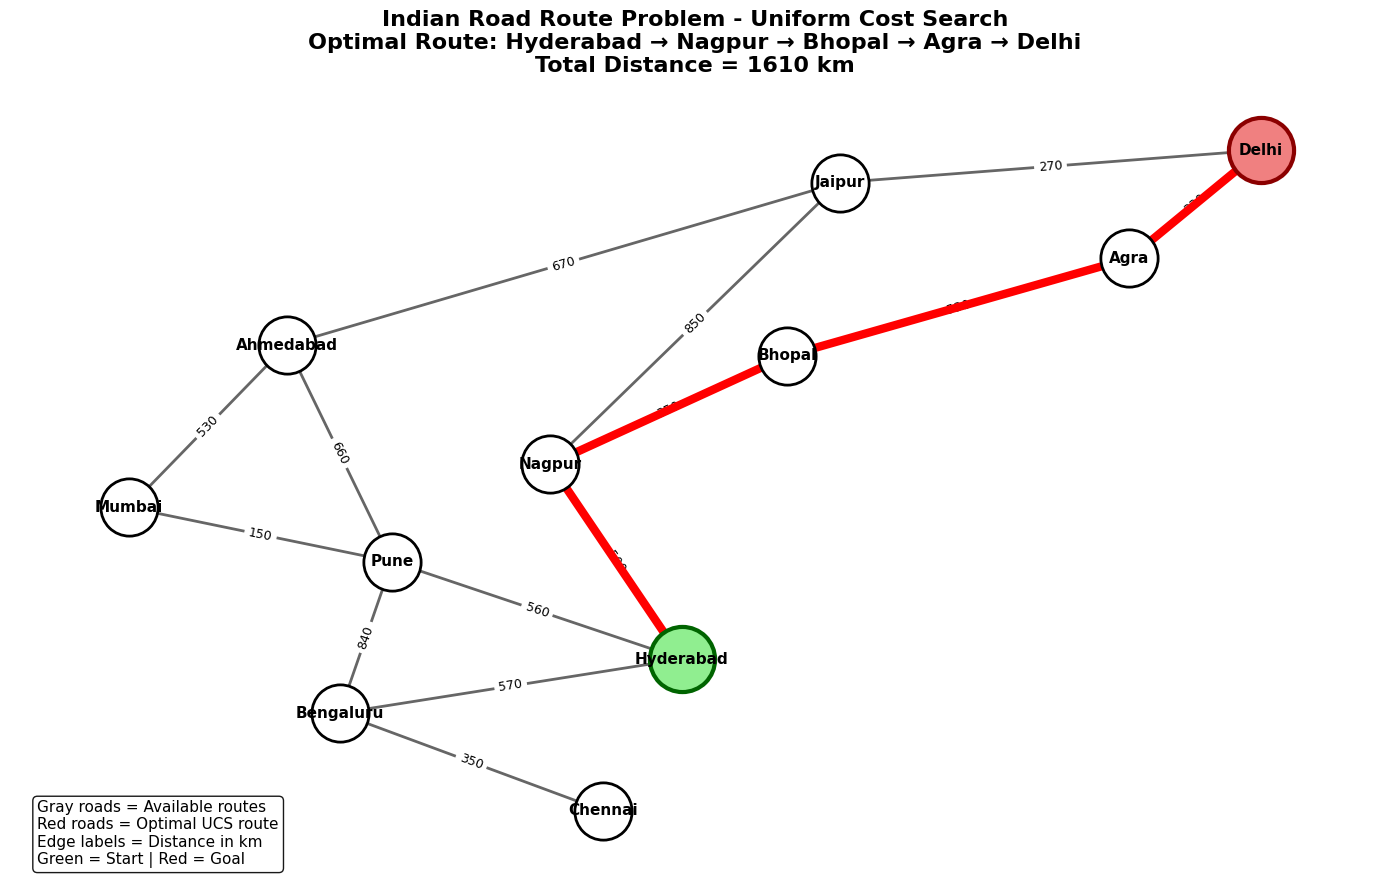

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Create Indian Road Graph
# -----------------------------------------

G = nx.Graph()

roads = [
    ("Hyderabad", "Nagpur", 500),
    ("Hyderabad", "Bengaluru", 570),
    ("Hyderabad", "Pune", 560),

    ("Nagpur", "Bhopal", 350),
    ("Nagpur", "Jaipur", 850),

    ("Bengaluru", "Chennai", 350),
    ("Bengaluru", "Pune", 840),

    ("Pune", "Mumbai", 150),
    ("Pune", "Ahmedabad", 660),

    ("Mumbai", "Ahmedabad", 530),

    ("Ahmedabad", "Jaipur", 670),

    ("Bhopal", "Agra", 530),

    ("Agra", "Delhi", 230),

    ("Jaipur", "Delhi", 270)
]

# Add roads to graph
for city1, city2, distance in roads:
    G.add_edge(city1, city2, weight=distance)


# -----------------------------------------
# 2. Define optimal route
# -----------------------------------------

optimal_path = [
    "Hyderabad",
    "Nagpur",
    "Bhopal",
    "Agra",
    "Delhi"
]

optimal_edges = list(zip(
    optimal_path,
    optimal_path[1:]
))


# -----------------------------------------
# 3. Position of cities
# -----------------------------------------

pos = {
    "Delhi": (5.5, 5.0),
    "Jaipur": (3.9, 4.7),
    "Agra": (5.0, 4.0),
    "Ahmedabad": (1.8, 3.2),
    "Bhopal": (3.7, 3.1),
    "Nagpur": (2.8, 2.1),
    "Mumbai": (1.2, 1.7),
    "Pune": (2.2, 1.2),
    "Hyderabad": (3.3, 0.3),
    "Bengaluru": (2.0, -0.2),
    "Chennai": (3.0, -1.1)
}


# -----------------------------------------
# 4. Draw all roads
# -----------------------------------------

plt.figure(figsize=(14, 9))

nx.draw_networkx_edges(
    G,
    pos,
    width=2,
    alpha=0.6
)


# -----------------------------------------
# 5. Draw cities
# -----------------------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1700,
    node_color="white",
    edgecolors="black",
    linewidths=2
)


# City names
nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold"
)


# -----------------------------------------
# 6. Display road distances
# -----------------------------------------

edge_labels = nx.get_edge_attributes(
    G,
    "weight"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9
)


# -----------------------------------------
# 7. Highlight optimal UCS route
# -----------------------------------------

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=optimal_edges,
    width=6,
    edge_color="red"
)


# -----------------------------------------
# 8. Highlight START and GOAL
# -----------------------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=["Hyderabad"],
    node_size=2200,
    node_color="lightgreen",
    edgecolors="darkgreen",
    linewidths=3
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=["Delhi"],
    node_size=2200,
    node_color="lightcoral",
    edgecolors="darkred",
    linewidths=3
)


# -----------------------------------------
# 9. Title
# -----------------------------------------

plt.title(
    "Indian Road Route Problem - Uniform Cost Search\n"
    "Optimal Route: Hyderabad → Nagpur → Bhopal → Agra → Delhi\n"
    "Total Distance = 1610 km",
    fontsize=16,
    fontweight="bold"
)


# -----------------------------------------
# 10. Legend / explanation
# -----------------------------------------

plt.text(
    0.02,
    0.02,
    "Gray roads = Available routes\n"
    "Red roads = Optimal UCS route\n"
    "Edge labels = Distance in km\n"
    "Green = Start | Red = Goal",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.9
    )
)

plt.axis("off")
plt.tight_layout()
plt.show()